# SegTHOR: Missing and invalid data checks

Different checks in CT volumes for "missing values":

1. File: patient folder without CT/GT, file that is truncated or won't decompress (3)
2. Header: spacing that is 0/NaN, broken affine, no coordinate system (4)
3. Voxel: NaN / ±Inf, non-integer labels (5)
4. Padding: a sentinel value (−1000, −1024, −2048, −3024…) filling the area outside the scanner's field of view (5)
5. Slice: blank/constant slices, duplicated slices (a missing slice filled with a copy) (5)
6. Anatomy: body cut off at the image border, organ cut off at the first/last slice (5)
7. Labels: organ missing on some slices *inside* its extent (annotation gap) (5)

## 1 Setup

In [ ]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import ndimage as ndi
from IPython.display import display


DATA_DIR = Path("data")            
DEST = Path("results/missing")
SAVE_FIGS = True
BODY_HU = -500                    
SENTINELS = [-1000, -1024, -2000, -2048, -3024, -32768]   
UPPER_CLAMPS = [3071, 4095, 32767]                      
MOSTLY_PADDING = 0.95            

CLASS_NAMES = {1: "Esophagus", 2: "Heart", 3: "Trachea", 4: "Aorta"}
COLOURS = {1: "#6fae6f", 2: "#f0d080", 3: "#b06a50", 4: "#5ab0d0"}
LABEL_CMAP = ListedColormap([COLOURS[k] for k in CLASS_NAMES])
DEST.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(DEST / name, dpi=130, bbox_inches="tight")

def window(img, lo=-160, hi=240):
    return (np.clip(img.astype(np.float32), lo, hi) - lo) / (hi - lo)

## 2 Check functions

In [ ]:
def file_check(path):
    # Fully decompress file
    try:
        image = nib.load(str(path))
        data = np.asarray(image.dataobj)
        return image, data, None
    except Exception as e:
        return None, None, f"{type(e).__name__}: {e}"

def header_check(image):
    zooms = np.array(image.header.get_zooms()[:3], dtype=float)
    affine = image.affine
    qform_code = int(image.get_qform(coded=True)[1])
    sform_code = int(image.get_sform(coded=True)[1])
    slope, inter = image.header.get_slope_inter()
    units = image.header.get_xyzt_units()[0]
    return {
        "spacing_ok": bool(np.isfinite(zooms).all() and (zooms > 0).all()),
        "affine_ok": bool(np.isfinite(affine).all() and abs(np.linalg.det(affine[:3, :3])) > 1e-6),
        "qform_code": qform_code, "sform_code": sform_code,
        "coords_defined": qform_code > 0 or sform_code > 0,
        "units": units,
        "slope_inter_ok": all(v is None or np.isfinite(v) for v in (slope, inter)),
    }

def voxel_check(ct):
    finite = np.isfinite(ct) if np.issubdtype(ct.dtype, np.floating) else np.ones(ct.shape, bool)
    vmin, vmax = ct[finite].min(), ct[finite].max()
    return {
        "ct_dtype": str(ct.dtype),
        "n_nan": int(np.isnan(ct).sum()) if np.issubdtype(ct.dtype, np.floating) else 0,
        "n_inf": int(np.isinf(ct).sum()) if np.issubdtype(ct.dtype, np.floating) else 0,
        "ct_min": float(vmin), "ct_max": float(vmax),
        "frac_at_min": float((ct == vmin).mean()),          # padding + clamped air
        "frac_at_max": float((ct == vmax).mean()),          # saturation
        "sentinels_found": [s for s in SENTINELS if s != vmin and (ct == s).any()],
        "max_is_clamp": float(vmax) in UPPER_CLAMPS,
    }

def slice_check(ct, vmin):
    Z = ct.shape[2]
    flat = ct.reshape(-1, Z)
    std = flat.std(axis=0)
    pad_frac = (flat == vmin).mean(axis=0)
    duplicate = np.array([np.array_equal(ct[:, :, z], ct[:, :, z + 1]) for z in range(Z - 1)] + [False])
    # Field of view: are the image corners padding? (typical circular reconstruction)
    c = 16
    corners = np.stack([ct[:c, :c], ct[:c, -c:], ct[-c:, :c], ct[-c:, -c:]])  # (4, c, c, Z)
    corner_pad = (corners == vmin).reshape(-1, Z).mean(axis=0)
    # Body touching the image border = anatomy possibly cut off in-plane
    body = ct > BODY_HU
    border = np.concatenate([body[0], body[-1], body[:, 0], body[:, -1]], axis=0)  # (4*512, Z)
    body_touch = border.sum(axis=0)
    return {"std": std, "pad_frac": pad_frac, "duplicate": duplicate,
            "corner_pad": corner_pad, "body_border_px": body_touch}

def label_check(gt):
    rec, per_slice = {}, {}
    values = np.unique(gt)
    rec["gt_dtype"] = str(gt.dtype)
    rec["gt_non_integer"] = bool(np.issubdtype(gt.dtype, np.floating) and not np.all(np.mod(values, 1) == 0))
    rec["gt_unexpected_values"] = [float(v) for v in values if v not in range(5)]
    Z = gt.shape[2]
    for k, name in CLASS_NAMES.items():
        present = (gt == k).any(axis=(0, 1))
        per_slice[k] = present
        n = name.lower()
        if not present.any():
            rec[f"{n}_missing"] = True
            rec[f"{n}_gaps"] = []
            continue
        first, last = int(np.argmax(present)), int(Z - 1 - np.argmax(present[::-1]))
        rec[f"{n}_missing"] = False
        rec[f"{n}_gaps"] = [int(z) for z in np.flatnonzero(~present[first:last + 1]) + first]
        rec[f"{n}_at_scan_edge"] = first == 0 or last == Z - 1      # organ cut by scan range
        m = gt == k
        rec[f"{n}_at_image_border"] = bool(m[0].any() or m[-1].any() or m[:, 0].any() or m[:, -1].any())
    return rec, per_slice

## 3 File-level (check if everything is present and readable)

In [ ]:
train_dir = DATA_DIR / "train"
assert train_dir.is_dir(), f"No train/ folder in {DATA_DIR.resolve()}"
patients = sorted(p for p in train_dir.glob("Patient_*") if p.is_dir())

ids = sorted(int(p.name.split("_")[1]) for p in patients if p.name.split("_")[1].isdigit())
missing_ids = sorted(set(range(ids[0], ids[-1] + 1)) - set(ids)) if ids else []

inventory = pd.DataFrame([{
    "patient": p.name,
    "CT exists": (p / f"{p.name}.nii.gz").is_file(),
    "GT exists": (p / "GT.nii.gz").is_file(),
    "CT size (MB)": round((p / f"{p.name}.nii.gz").stat().st_size / 1e6, 1) if (p / f"{p.name}.nii.gz").is_file() else None,
    "GT size (MB)": round((p / "GT.nii.gz").stat().st_size / 1e6, 2) if (p / "GT.nii.gz").is_file() else None,
} for p in patients])

print(f"{len(patients)} patient folders. Numbering gaps: {missing_ids if missing_ids else 'none'}")
problems = inventory[~(inventory["CT exists"] & inventory["GT exists"])]
print("Missing files:", "none" if problems.empty else "")
if not problems.empty: display(problems)

small = inventory[inventory["CT size (MB)"] < 0.3 * inventory["CT size (MB)"].median()]
print("Suspiciously small CT files:", "none" if small.empty else "")
if not small.empty: display(small)

40 patient folders. Numbering gaps: none
Missing files: none
Suspiciously small CT files: none


## 4,5 Header, voxel, slice and label checks

The live figure shows, for the current patient: per-slice padding fraction and flagged slices (left) and which slices each organ appears on, with gaps marked in red (right).

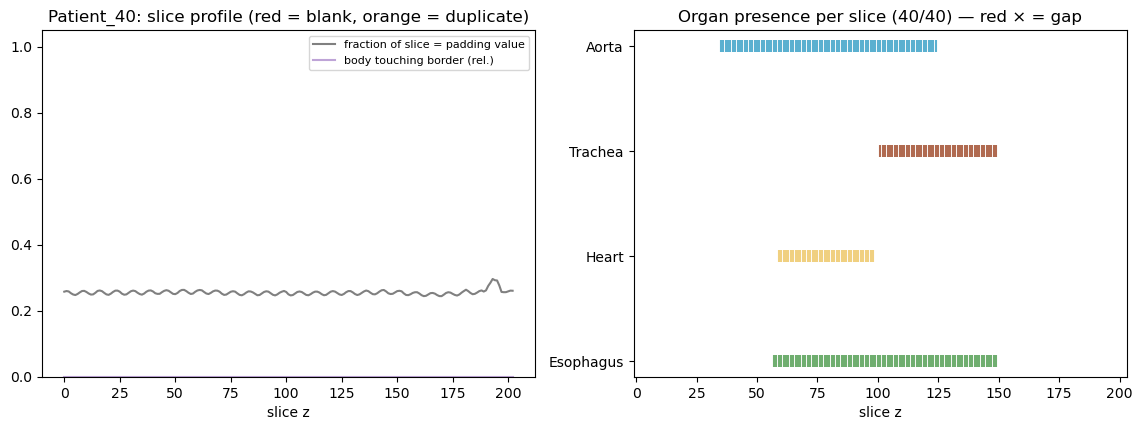

Checked 40 patients — 1 issue(s) found.


In [ ]:
rows, slice_info, label_presence, issues = [], {}, {}, []

live_fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 4.5))
handle = display(live_fig, display_id=True)
plt.close(live_fig)

for n, pdir in enumerate(patients, 1):
    pid = pdir.name
    row = {"patient": pid}
    ct_img, ct, ct_err = file_check(pdir / f"{pid}.nii.gz")
    gt_img, gt, gt_err = file_check(pdir / "GT.nii.gz")
    if ct_err or gt_err:
        row["read_error"] = ct_err or gt_err
        issues.append(f"{pid}: cannot read — {row['read_error']}")
        rows.append(row)
        continue

    # Header
    h = header_check(ct_img)
    row |= {f"ct_{k}": v for k, v in h.items()}
    hg = header_check(gt_img)
    row["gt_coords_defined"] = hg["coords_defined"]
    row["same_shape"] = ct.shape == gt.shape
    row["same_affine"] = bool(np.allclose(ct_img.affine, gt_img.affine, atol=1e-3))
    for k in ["spacing_ok", "affine_ok", "coords_defined", "slope_inter_ok"]:
        if not h[k]: issues.append(f"{pid}: CT header problem — {k} is False")
    if not hg["coords_defined"]: issues.append(f"{pid}: GT has no coordinate system (qform/sform codes 0)")
    if not row["same_shape"]:
        issues.append(f"{pid}: CT {ct.shape} vs GT {gt.shape}"); rows.append(row); continue
    if not row["same_affine"]: issues.append(f"{pid}: CT and GT affines differ")

    # Voxels
    v = voxel_check(ct)
    row |= v
    if v["n_nan"] or v["n_inf"]: issues.append(f"{pid}: {v['n_nan']} NaN and {v['n_inf']} Inf voxels")
    if v["sentinels_found"]: issues.append(f"{pid}: other fill values present {v['sentinels_found']}")

    # Slices
    s = slice_check(ct, v["ct_min"])
    slice_info[pid] = s
    const = np.flatnonzero(s["std"] == 0)
    mostly_pad = np.flatnonzero(s["pad_frac"] > MOSTLY_PADDING)
    dup = np.flatnonzero(s["duplicate"])
    row |= {"n_slices": ct.shape[2], "constant_slices": const.tolist(),
            "mostly_padding_slices": mostly_pad.tolist(), "duplicate_slices": dup.tolist(),
            "fov_corners_padded": bool(np.median(s["corner_pad"]) > .99),
            "slices_body_touches_border": int((s["body_border_px"] > 0).sum())}
    if len(const): issues.append(f"{pid}: constant (blank) slices {const.tolist()}")
    if len(dup): issues.append(f"{pid}: slice identical to the next one at z={dup.tolist()}")
    if len(mostly_pad): issues.append(f"{pid}: {len(mostly_pad)} slices are >{MOSTLY_PADDING:.0%} padding")

    # Labels
    lrec, presence = label_check(gt)
    row |= lrec
    label_presence[pid] = presence
    if lrec["gt_non_integer"] or lrec["gt_unexpected_values"]:
        issues.append(f"{pid}: GT has non-integer or unexpected values {lrec['gt_unexpected_values']}")
    for k, name in CLASS_NAMES.items():
        nm = name.lower()
        if lrec[f"{nm}_missing"]: issues.append(f"{pid}: {name} absent")
        if lrec.get(f"{nm}_gaps"): issues.append(f"{pid}: {name} missing on slices {lrec[f'{nm}_gaps']} inside its extent")
        if lrec.get(f"{nm}_at_scan_edge"): issues.append(f"{pid}: {name} touches first/last slice (may be cut off)")
        if lrec.get(f"{nm}_at_image_border"): issues.append(f"{pid}: {name} touches the image border")
    rows.append(row)


    ax_a.clear(); ax_b.clear()
    z = np.arange(ct.shape[2])
    ax_a.plot(z, s["pad_frac"], label="fraction of slice = padding value", color="grey")
    ax_a.plot(z, s["body_border_px"] / s["body_border_px"].max() if s["body_border_px"].max() else 0 * z,
              label="body touching border (rel.)", color="tab:purple", alpha=.6)
    for zz in const: ax_a.axvline(zz, color="red", lw=2)
    for zz in dup: ax_a.axvline(zz, color="orange", lw=2)
    ax_a.set(xlabel="slice z", ylim=(0, 1.05), title=f"{pid}: slice profile (red = blank, orange = duplicate)")
    ax_a.legend(fontsize=8, loc="upper right")
    for i, (k, name) in enumerate(CLASS_NAMES.items()):
        p = presence[k]
        ax_b.scatter(z[p], np.full(p.sum(), i), marker="|", s=80, color=COLOURS[k])
        gaps = lrec.get(f"{name.lower()}_gaps", [])
        ax_b.scatter(gaps, np.full(len(gaps), i), marker="x", s=60, color="red")
    ax_b.set_yticks(range(4)); ax_b.set_yticklabels(CLASS_NAMES.values())
    ax_b.set(xlabel="slice z", xlim=(-1, ct.shape[2]),
             title=f"Organ presence per slice ({n}/{len(patients)}) — red × = gap")
    handle.update(live_fig)
    del ct, gt

report = pd.DataFrame(rows)
report.to_csv(DEST / "missing_report.csv", index=False)
print(f"Checked {len(rows)} patients — {len(issues)} issue(s) found.")

## 6. Issues found

In [5]:
if issues:
    for i in issues: print("•", i)
else:
    print("No missing or invalid data found at any level.")
(DEST / "issues.txt").write_text("\n".join(issues) if issues else "none")

• Patient_35: Aorta touches first/last slice (may be cut off)


59

## 7. Summary table

One row per patient, one column per check.

In [6]:
gap_cols = [f"{n.lower()}_gaps" for n in CLASS_NAMES.values()]
summary = pd.DataFrame({
    "patient": report["patient"],
    "readable": report.get("read_error", pd.Series([None] * len(report))).isna(),
    "header ok": report[["ct_spacing_ok", "ct_affine_ok", "ct_coords_defined", "ct_slope_inter_ok"]].all(axis=1),
    "CT/GT aligned": report["same_shape"] & report["same_affine"],
    "NaN/Inf": report["n_nan"] + report["n_inf"],
    "fill value": report["ct_min"],
    "% at fill value": (100 * report["frac_at_min"]).round(1),
    "max (clamp?)": report["ct_max"].astype(int).astype(str) + np.where(report["max_is_clamp"], " (clamp)", ""),
    "blank slices": report["constant_slices"].apply(len),
    "duplicate slices": report["duplicate_slices"].apply(len),
    "FOV corners padded": report["fov_corners_padded"],
    "slices w/ body at border": report["slices_body_touches_border"],
    "label gaps (slices)": report[gap_cols].apply(lambda r: sum(len(g) for g in r), axis=1),
})

def highlight(v, col):
    bad = {"readable": v is False, "header ok": v is False, "CT/GT aligned": v is False,
           "NaN/Inf": v != 0, "blank slices": v != 0, "duplicate slices": v != 0,
           "label gaps (slices)": v != 0}.get(col, False)
    return "background-color: #f8c8c8" if bad else ""

display(summary.style.apply(lambda c: [highlight(v, c.name) for v in c]))

,patient,readable,header ok,CT/GT aligned,NaN/Inf,fill value,% at fill value,max (clamp?),blank slices,duplicate slices,FOV corners padded,slices w/ body at border,label gaps (slices)
0,Patient_01,True,True,True,0,-1000.000000,40.800000,3071 (clamp),0,0,True,0,0
1,Patient_02,True,True,True,0,-1000.000000,27.100000,26613,0,0,True,0,0
2,Patient_03,True,True,True,0,-1000.000000,25.900000,25292,0,0,True,0,0
3,Patient_04,True,True,True,0,-1000.000000,25.400000,4551,0,0,True,158,0
4,Patient_05,True,True,True,0,-1000.000000,43.000000,3071 (clamp),0,0,True,0,0
5,Patient_06,True,True,True,0,-1000.000000,42.600000,3071 (clamp),0,0,True,8,0
6,Patient_07,True,True,True,0,-1000.000000,38.400000,3059,0,0,True,0,0
7,Patient_08,True,True,True,0,-1000.000000,43.100000,3071 (clamp),0,0,True,171,0
8,Patient_09,True,True,True,0,-1000.000000,45.300000,3071 (clamp),0,0,True,0,0
9,Patient_10,True,True,True,0,-1000.000000,34.500000,3071 (clamp),0,0,True,0,0


## 8 Padding and field of view

The fill value (the scan minimum) covers both genuine air and the area outside the scanner's reconstruction circle. The fill value is the same everywhere (so a fixed HU window treats it consistently), and no other sentinel values are mixed in.

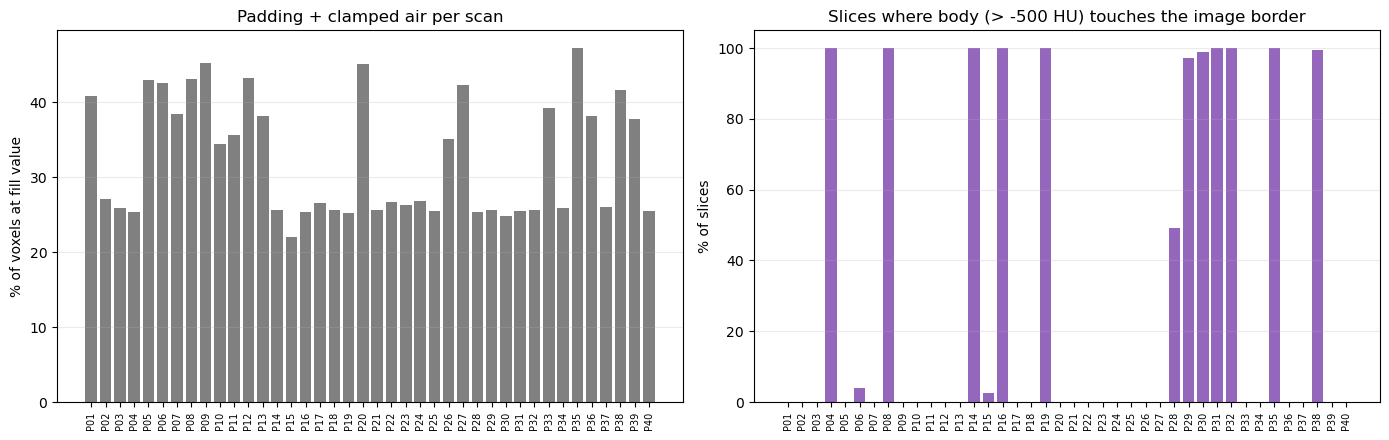

Fill values found: [-1000.0] | other sentinels anywhere: none


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(report["patient"].str.replace("Patient_", "P"), 100 * report["frac_at_min"], color="grey")
axes[0].set(ylabel="% of voxels at fill value", title="Padding + clamped air per scan")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[1].bar(report["patient"].str.replace("Patient_", "P"),
            100 * report["slices_body_touches_border"] / report["n_slices"], color="tab:purple")
axes[1].set(ylabel="% of slices", title=f"Slices where body (> {BODY_HU} HU) touches the image border")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
for ax in axes: ax.grid(axis="y", alpha=.25)
fig.tight_layout(); save(fig, "01_padding_fov.png"); plt.show()
print("Fill values found:", sorted(report["ct_min"].unique()),
      "| other sentinels anywhere:", sorted({s for l in report["sentinels_found"] for s in l}) or "none")

Body touching the border is often just the scanner table or the arms, which is harmless. Below are the slices where it happens most for the worst patient, so you can judge.

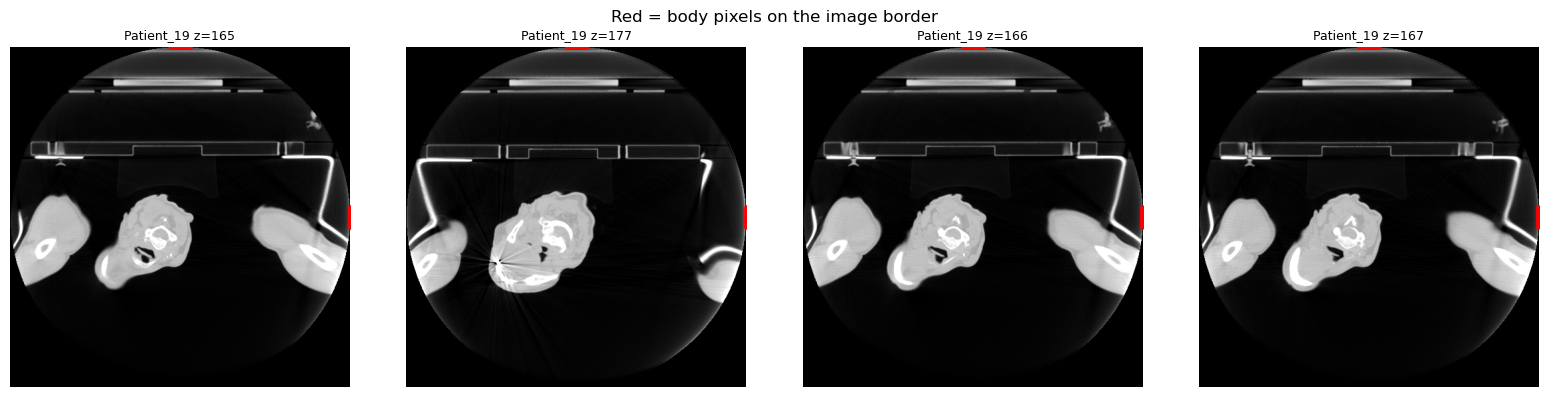

In [9]:
worst = report.sort_values("slices_body_touches_border", ascending=False)["patient"].iloc[0]
s = slice_info[worst]
zs = np.argsort(s["body_border_px"])[::-1][:4]
ct = np.asarray(nib.load(str(train_dir / worst / f"{worst}.nii.gz")).dataobj)
fig, axes = plt.subplots(1, len(zs), figsize=(4 * len(zs), 4))
for ax, z in zip(np.atleast_1d(axes), zs):
    ax.imshow(window(ct[:, :, z], -1000, 400).T, cmap="gray", origin="lower")
    edge = np.zeros(ct.shape[:2], bool)
    b = ct[:, :, z] > BODY_HU
    edge[0], edge[-1], edge[:, 0], edge[:, -1] = b[0], b[-1], b[:, 0], b[:, -1]
    ys, xs = np.nonzero(edge.T)
    ax.scatter(xs, ys, s=4, color="red")
    ax.set_title(f"{worst} z={z}", fontsize=9); ax.axis("off")
fig.suptitle("Red = body pixels on the image border"); fig.tight_layout()
save(fig, "02_border_examples.png"); plt.show()
del ct

## 9. Label gaps — look at them

An organ missing on a slice in the middle of its extent is the label equivalent of a missing value. A 2D network trained on that slice is taught that the organ is absent there. Pick a patient from the issues list to view the gap and its neighbours.

In [10]:
gappy = report[report[gap_cols].apply(lambda r: sum(len(g) for g in r), axis=1) > 0]
print("Patients with label gaps:", gappy["patient"].tolist() or "none")

PATIENT = gappy["patient"].iloc[0] if len(gappy) else None   # change to inspect another
if PATIENT:
    r = report.set_index("patient").loc[PATIENT]
    k, name = next((k, n) for k, n in CLASS_NAMES.items() if r[f"{n.lower()}_gaps"])
    z = r[f"{name.lower()}_gaps"][0]
    ct = np.asarray(nib.load(str(train_dir / PATIENT / f"{PATIENT}.nii.gz")).dataobj)
    gt = np.asarray(nib.load(str(train_dir / PATIENT / "GT.nii.gz")).dataobj)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, zz in zip(axes, [z - 1, z, z + 1]):
        if not 0 <= zz < ct.shape[2]: ax.axis("off"); continue
        ax.imshow(window(ct[:, :, zz]).T, cmap="gray", origin="lower")
        g = gt[:, :, zz]
        ax.imshow(np.ma.masked_where(g.T == 0, g.T), cmap=LABEL_CMAP, vmin=.5, vmax=4.5,
                  alpha=.55, origin="lower", interpolation="nearest")
        ax.set_title(f"z={zz}" + ("  ← gap" if zz == z else ""), fontsize=10); ax.axis("off")
    fig.suptitle(f"{PATIENT}: {name} label gap")
    save(fig, f"03_gap_{PATIENT}.png"); plt.show()
    del ct, gt

Patients with label gaps: none


- **NaN/Inf, unreadable files, header problems, CT/GT misalignment**
- **one fill value is expected, not more than one**: one is handled by a fixed HU window Several different fill values would need mapping to a single one first
- **Check clamp value (3071, 4095) clipping**
- **Blank or duplicated slices**
- **Body touching the border**
- **Organ at first/last slice**: the organ continues outside the scan
- **Label gaps**.